Завдання, що пропонуються, необхідно оформити у вигляді одного jupyter ноутбука.

**Завдання 1** 

У цьому завданні вам потрібно завантажити ось цей датасет. Тут ви знайдете 2 файли - з двовимірним датасетом та датасетом mnist. Для кожного з них застосуйте алгоритм K-means для кластеризації. Щоб знайти оптимальну кількість кластерів, скористайтесь ліктевим методом.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


In [2]:
two_dimensional_df = pd.read_csv('data_hw_6/data_2d.csv')
two_dimensional_df.columns = ['label', 'Feature-1','Feature-2']
two_dimensional_df.head(5)

,label,Feature-1,Feature-2
0,0.0,2.687848,2.366961
1,0.0,-0.201379,0.470430
2,0.0,0.608496,1.225400
3,0.0,-0.082282,1.137218
4,0.0,2.083069,2.694482


In [3]:
two_dimensional_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   label      199 non-null    float64
 1   Feature-1  199 non-null    float64
 2   Feature-2  199 non-null    float64
dtypes: float64(3)
memory usage: 4.8 KB


In [4]:
two_dimensional_df.describe()

,label,Feature-1,Feature-2
count,199.000000,199.000000,199.000000
mean,0.502513,1.771587,2.220299
std,0.501255,1.230001,1.604383
min,0.000000,-1.488928,-1.344141
25%,0.000000,0.880885,0.979439
50%,1.000000,1.736607,2.283748
75%,1.000000,2.707277,3.608612
max,1.000000,4.554605,5.722027


In [5]:
two_dimensional_df.duplicated().sum()

np.int64(0)

In [6]:
mnist_df = pd.read_csv('data_hw_6/mnist.csv')
mnist_df.columns = ['label'] + [f'pix_{i}' for i in range(mnist_df.shape[1]-1)]
mnist_df.head()

,label,pix_0,pix_1,pix_2,pix_3,pix_4,pix_5,pix_6,pix_7,pix_8,...,pix_774,pix_775,pix_776,pix_777,pix_778,pix_779,pix_780,pix_781,pix_782,pix_783
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
mnist_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Columns: 785 entries, label to pix_783
dtypes: int64(785)
memory usage: 3.0 MB


In [8]:
mnist_df.describe()

,label,pix_0,pix_1,pix_2,pix_3,pix_4,pix_5,pix_6,pix_7,pix_8,...,pix_774,pix_775,pix_776,pix_777,pix_778,pix_779,pix_780,pix_781,pix_782,pix_783
count,499.000000,499.0,499.0,499.0,499.0,499.0,499.0,499.0,499.0,499.0,...,499.000000,499.000000,499.0,499.0,499.0,499.0,499.0,499.0,499.0,499.0
mean,4.372745,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.507014,0.256513,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,2.874437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,11.325835,5.730067,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,128.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
mnist_df.duplicated().sum()

np.int64(0)

алгоритм K-means для кластеризації двовимірного набору даних (two_dimensional_df)

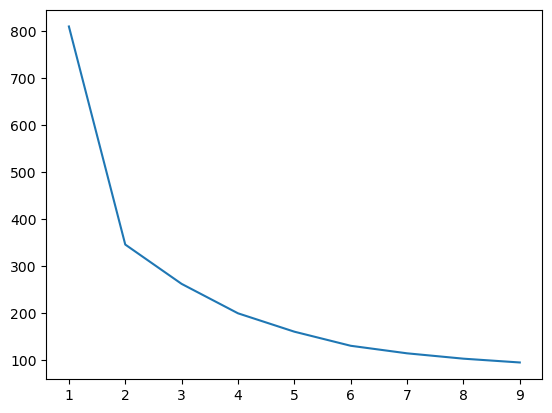

In [10]:
inertial_values = []
features = two_dimensional_df[['Feature-1','Feature-2']]
for i in range(1,10):
    kmeans = KMeans(n_clusters=i,init='random',n_init='auto',max_iter=10,tol=1e-04,algorithm="lloyd",random_state=19)
    y_km = kmeans.fit_predict(features)
    inertial_values.append(kmeans.inertia_)

plt.plot(range(1,10), inertial_values)

In [11]:
inertial_values

[809.2157980450891,
 345.76431862173735,
 262.17469326630965,
 199.62893954744607,
 160.57922511537495,
 130.63111292723838,
 114.58795110490668,
 103.20775776164245,
 95.13304212251049]

Графік показує, що в точці 2 на графіку утворюється вигин, що свідчить про те, що 2 — це оптимальна кількість кластерів 

кластеризація для двовимірного набору даних (two_dimensional_df)

In [12]:
n_clusters = 2
kmeans_td = KMeans(n_clusters=n_clusters,init='random',n_init='auto',max_iter=10,tol=1e-04,algorithm="lloyd",random_state=19)
y_km = kmeans_td.fit_predict(features)
kmeans_td.inertia_, kmeans_td.cluster_centers_

(345.76431862173735,
 array([[0.99657712, 0.80580517],
        [2.46540572, 3.48660748]]))

In [13]:
y_km

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1], dtype=int32)

алгоритм K-means для кластеризації mnist набору даних (mnist_df)

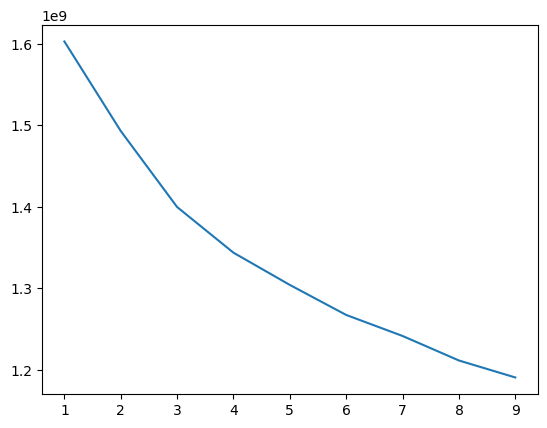

In [14]:
inertial_values = []
mnist_copy = mnist_df.copy()
mnist_X = mnist_copy.drop(columns='label')
for i in range(1,10):
    kmeans = KMeans(n_clusters=i,init='random',n_init='auto',max_iter=300,tol=1e-04,algorithm="lloyd",random_state=19)
    y_km_2d = kmeans.fit_predict(mnist_X)
    inertial_values.append(kmeans.inertia_)

plt.plot(range(1,10),inertial_values)

In [15]:
inertial_values

[1602780496.529058,
 1493035812.6075778,
 1399853853.2915735,
 1343876196.35949,
 1304365730.1102953,
 1267572270.65124,
 1241799620.1544845,
 1211744366.9075127,
 1190930463.526788]

На графіку не дуже добре видно точку вигину, але, судячи з усього, це 3 або 4 => для остаточного визначення буде використано KneeLocator з модуля kneed.  

In [16]:
from kneed import KneeLocator
kl = KneeLocator(range(1,10), inertial_values,curve="convex", direction="decreasing")
print(kl.elbow)

4


алгоритм K-means для кластеризації mnist набору даних (mnist_df)

In [17]:
kmeans_mnist = KMeans(n_clusters=4,init='random',n_init='auto',max_iter=300,tol=1e-04, algorithm='lloyd',random_state=19)
y_km_mnist = kmeans_mnist.fit_predict(mnist_X)
y_km_mnist

array([2, 1, 3, 0, 1, 0, 0, 0, 0, 3, 3, 0, 3, 1, 2, 0, 0, 2, 0, 1, 2, 0,
       2, 0, 3, 0, 0, 3, 1, 2, 1, 2, 3, 1, 3, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       2, 1, 1, 0, 0, 2, 2, 2, 2, 3, 2, 0, 1, 0, 1, 0, 3, 0, 1, 0, 0, 3,
       0, 2, 3, 0, 3, 3, 1, 1, 1, 2, 0, 1, 0, 0, 3, 3, 0, 0, 0, 1, 2, 3,
       1, 2, 1, 1, 2, 1, 0, 1, 1, 3, 0, 1, 3, 2, 0, 0, 0, 3, 1, 0, 0, 2,
       1, 1, 0, 1, 1, 0, 0, 0, 3, 2, 1, 0, 3, 0, 0, 3, 2, 2, 2, 3, 3, 2,
       0, 2, 1, 3, 1, 3, 0, 1, 0, 2, 1, 0, 1, 0, 3, 3, 1, 0, 0, 1, 2, 1,
       2, 0, 3, 2, 1, 0, 3, 2, 0, 0, 2, 0, 1, 1, 0, 0, 1, 2, 2, 1, 1, 1,
       2, 1, 2, 1, 2, 2, 3, 2, 0, 2, 2, 3, 1, 1, 1, 3, 0, 3, 1, 1, 1, 0,
       3, 2, 3, 1, 1, 1, 2, 0, 2, 3, 0, 0, 1, 0, 1, 0, 3, 2, 1, 1, 2, 0,
       3, 3, 0, 1, 2, 2, 1, 1, 1, 1, 1, 2, 0, 1, 0, 1, 1, 0, 1, 2, 2, 2,
       0, 1, 1, 3, 1, 0, 1, 0, 1, 0, 2, 0, 0, 1, 1, 3, 3, 2, 1, 0, 1, 1,
       1, 2, 1, 2, 3, 2, 3, 1, 0, 0, 0, 1, 2, 3, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 2, 0, 2, 0, 1, 3, 0, 3, 3, 3, 2, 1, 0,

**Завдання 2**


Візуалізуйте результат роботи кластеризації. Для випадку з mnist датасетом, вам потрібно ще скористатись алгоритмом PCA щоб зменшити розмірність вашим даних до 2-вимірного варіанту.

1. Візуалізація результату двовимірного набору даних (two_dimensional_df)

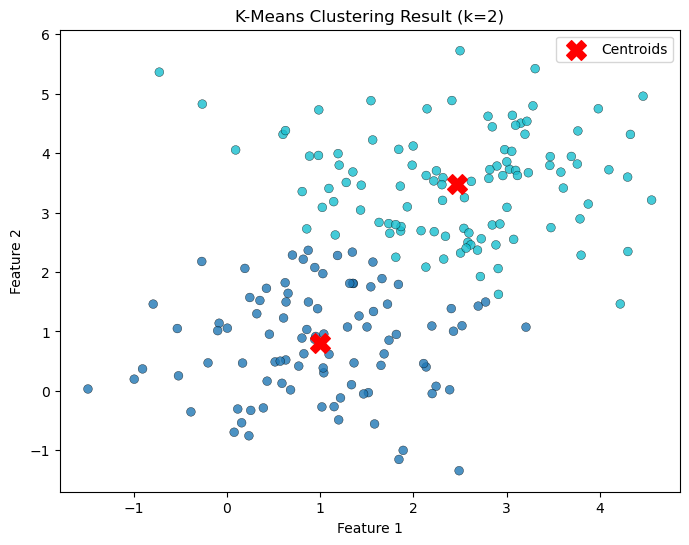

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(features['Feature-1'], features['Feature-2'], c=y_km,cmap='tab10', s=40, alpha=0.8, edgecolor='k', linewidth=0.3)
plt.scatter(kmeans_td.cluster_centers_[:, 0], kmeans_td.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'K-Means Clustering Result (k={n_clusters})')
plt.legend()
plt.show()

2. Візуалізація результату mnist набору даних (mnist_df)

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X_norm = StandardScaler().fit_transform(mnist_X)
X_norm

pca = PCA(n_components=2,random_state=19)
principal_components = pca.fit_transform(X_norm)
# principal_components

In [ ]:
inertial_values = []
mnist_copy = mnist_df.copy()
mnist_X = mnist_copy.drop(columns='label')
for i in range(1,10):
    kmeans = KMeans(n_clusters=i,init='random',n_init='auto',max_iter=300,tol=1e-04,algorithm="lloyd",random_state=19)
    y_km_2d = kmeans.fit_predict(mnist_X)
    inertial_values.append(kmeans.inertia_)

plt.plot(range(1,10),inertial_values)

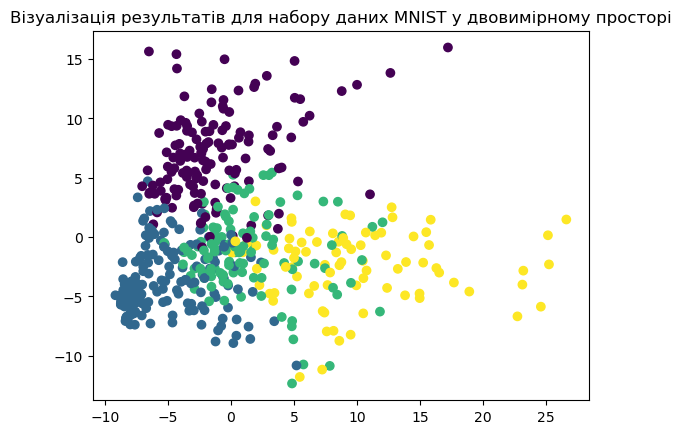

In [20]:
plt.scatter(principal_components[:,0],principal_components[:,1],c=y_km_mnist,cmap='viridis')
plt.title('Візуалізація результатів для набору даних MNIST у двовимірному просторі')
plt.show()